# ***Use all available features — do not apply feature selection before training***

# **Bryant Kenzo P. Carolino** | **2DSA-2**

## **ABSTRACT**
This project evaluates ten different machine learning models to predict whether an individual earns more than $50,000 a year based on demographic and employment data. The assessment compares traditional models such as Linear Probability Models and Logistic Regressions with varying levels of regularization against advanced tree-based algorithms like Random Forest and Gradient Boosting. The analysis reveals that Gradient Boosting is the superior model. Gradient Boosting achieved the highest overall accuracy (88%) and proved to be the most effective at accurately identifying high-income individuals.

# **Assessment 7: Regularization and Advanced Classification**

In [89]:
!pip install xgboost

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, 
                           precision_recall_curve, mean_squared_error, 
                           mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import pdist, squareform
from scipy import stats
import xgboost as xgb
from scipy.stats import entropy
import time
import warnings
warnings.filterwarnings('ignore')

In [91]:
# Set random seed for reproducibility
np.random.seed(42)

## **1. Data Preparation and EDA (5 points)**

### Load the Adult Income dataset

In [94]:
# Source - https://stackoverflow.com/q/54365045
# Posted by Inglorion, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-31, License - CC BY-SA 4.0

from sklearn.datasets import fetch_openml
dataset = fetch_openml("Adult-Census-Income")

# Converting the dataset into a Pandas dataframe
dataset = pd.DataFrame(data=dataset.data, 
                  columns=dataset.feature_names)

### Handle missing values, and encode categorical variables

In [96]:
# Check for missing values
print("\nMissing values by column:")
missing_values = dataset.isnull().sum()
print(missing_values[missing_values > 0])

# Create a working copy of the dataset
df = dataset.copy()


Missing values by column:
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [97]:
# =============================================================================
# FIX: STANDARDIZE COLUMN NAMES
# =============================================================================

# 1. Clean column names (replace hyphens/dots with underscores, lower case)
# This fixes mismatches like 'education-num' vs 'education_num' or 'Workclass' vs 'workclass'
df.columns = df.columns.str.lower().str.replace('-', '_').str.replace('.', '_')

# 2. Verify the fix
print("Corrected Column Names:")
print(df.columns.tolist())

# Check specifically for the ones needed in prepare_features
required_cols = ['workclass', 'education_num', 'marital_status', 'occupation', 
                 'relationship', 'race', 'sex', 'native_country']
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print(f"\n⚠️ STILL MISSING: {missing}")
else:
    print("\n✅ All required feature columns are present!")

Corrected Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

✅ All required feature columns are present!


#### ***Claude-generated code to determine how to appropriately handle the missing data***

MISSING VALUES SUMMARY

workclass:
  Missing: 1,836 (5.64%)
  Unique values (excl. missing): 8
  Most frequent: 'Private'

occupation:
  Missing: 1,843 (5.66%)
  Unique values (excl. missing): 14
  Most frequent: 'Prof-specialty'

native_country:
  Missing: 583 (1.79%)
  Unique values (excl. missing): 41
  Most frequent: 'United-States'

MISSINGNESS vs TARGET VARIABLE (Income)

Target column found: 'income'

WORKCLASS - Income distribution:
--------------------------------------------------
         Missing   Present
income                    
50K     0.104031  0.248983
=50K    0.895969  0.751017
  ⚠️  NOTABLE DIFFERENCE: 14.50% - consider 'Missing' category!

OCCUPATION - Income distribution:
--------------------------------------------------
         Missing  Present
income                   
50K     0.103635  0.24904
=50K    0.896365  0.75096
  ⚠️  NOTABLE DIFFERENCE: 14.54% - consider 'Missing' category!

NATIVE_COUNTRY - Income distribution:
---------------------------------------

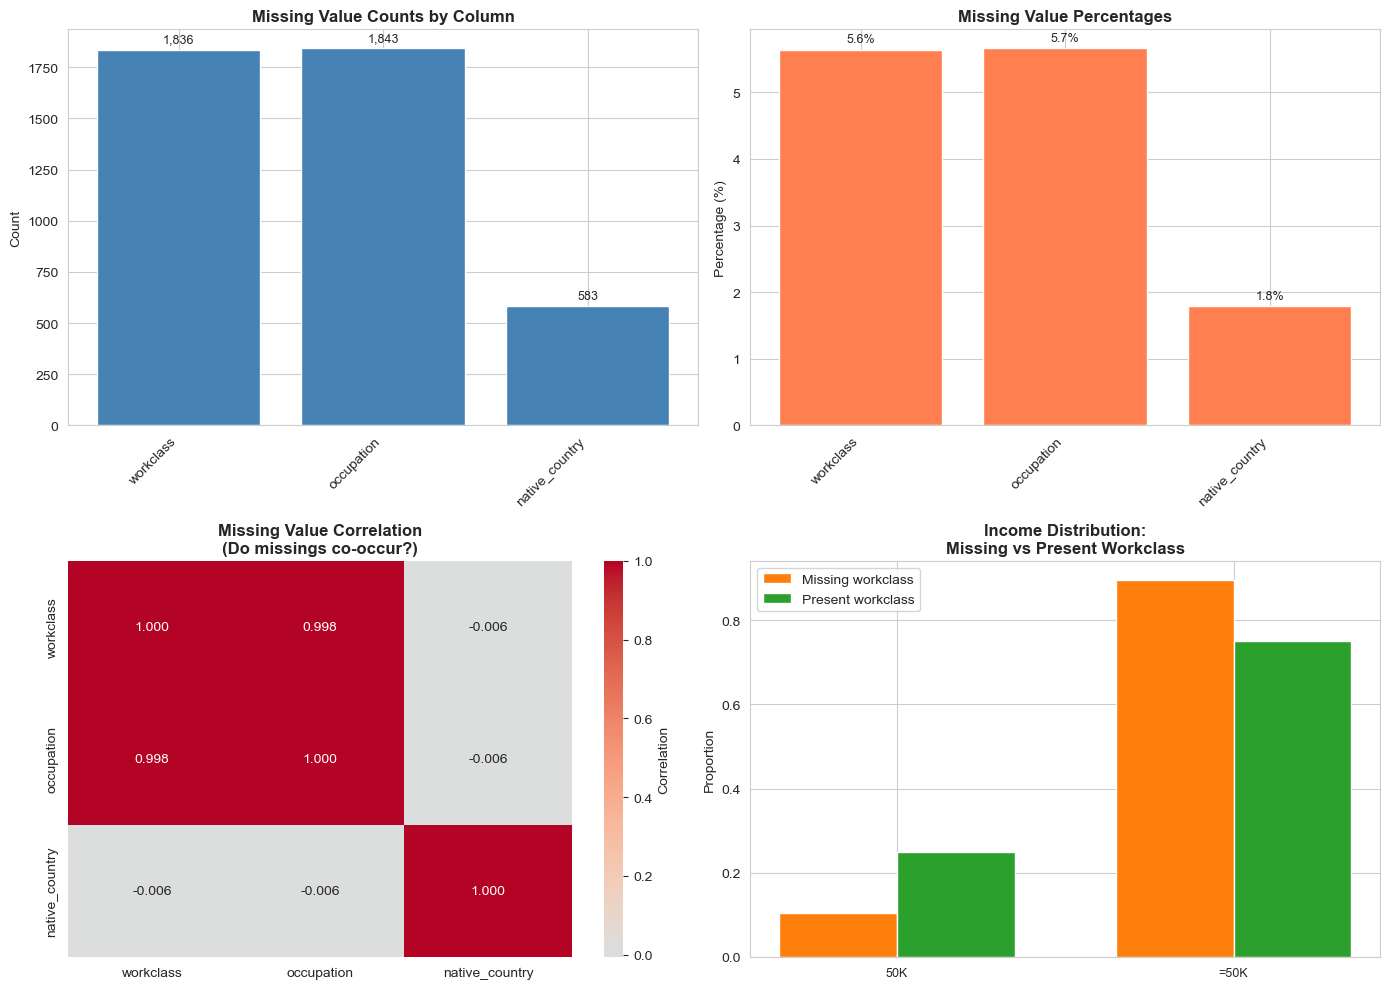


✓ Visualizations complete!

IMPUTATION STRATEGIES

workclass:
  Most frequent: 'Private' (73.9% of non-missing)
  Option 1: df['workclass'].fillna('Private')  # Mode imputation
  Option 2: df['workclass'].fillna('Missing')     # Missing indicator

occupation:
  Most frequent: 'Prof-specialty' (13.5% of non-missing)
  Option 1: df['occupation'].fillna('Prof-specialty')  # Mode imputation
  Option 2: df['occupation'].fillna('Missing')     # Missing indicator

native_country:
  Most frequent: 'United-States' (91.2% of non-missing)
  Option 1: df['native_country'].fillna('United-States')  # Mode imputation
  Option 2: df['native_country'].fillna('Missing')     # Missing indicator

RECOMMENDATION FOR YOUR LPM

Based on your analysis above:

✓ If missingness is RANDOM (similar income distributions):
  → Use MODE IMPUTATION
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna(df[col].mode()[0], inplace=True)

✓ 

In [99]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# =============================================================================
# STEP 1: QUICK MISSING VALUES OVERVIEW
# =============================================================================

print("="*70)
print("MISSING VALUES SUMMARY")
print("="*70)

missing_cols = ['workclass', 'occupation', 'native_country']

for col in missing_cols:
    if col in df.columns:
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / len(df)) * 100
        unique_vals = df[col].nunique()
        print(f"\n{col}:")
        print(f"  Missing: {missing_count:,} ({missing_pct:.2f}%)")
        print(f"  Unique values (excl. missing): {unique_vals}")
        if missing_pct < 100:
            top_val = df[col].mode()[0] if not df[col].mode().empty else 'N/A'
            print(f"  Most frequent: '{top_val}'")

# =============================================================================
# STEP 2: CHECK IF MISSINGNESS RELATES TO YOUR TARGET
# =============================================================================

print("\n" + "="*70)
print("MISSINGNESS vs TARGET VARIABLE (Income)")
print("="*70)

# Try common target column names
target_col = None
for possible_target in ['income', 'class', 'target', 'Income', 'Class']:
    if possible_target in df.columns:
        target_col = possible_target
        break

if target_col:
    print(f"\nTarget column found: '{target_col}'")
    
    for col in missing_cols:
        if col in df.columns:
            print(f"\n{col.upper()} - Income distribution:")
            print("-" * 50)
            
            # Compare income distribution for missing vs non-missing
            missing_mask = df[col].isna()
            
            if missing_mask.sum() > 0:
                missing_income = df[missing_mask][target_col].value_counts(normalize=True).sort_index()
                present_income = df[~missing_mask][target_col].value_counts(normalize=True).sort_index()
                
                comparison = pd.DataFrame({
                    'Missing': missing_income,
                    'Present': present_income
                })
                print(comparison)
                
                # Check if distributions are very different
                diff = abs(comparison['Missing'] - comparison['Present']).max()
                if diff > 0.05:
                    print(f"  ⚠️  NOTABLE DIFFERENCE: {diff:.2%} - consider 'Missing' category!")
                else:
                    print(f"  ✓ Similar distributions - mode imputation is fine")
else:
    print("\n⚠️  Target column not found. Common names: 'income', 'class', 'target'")
    print("Please specify your target column name.")

# =============================================================================
# STEP 3: MISSING VALUE OVERLAP ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("MISSING VALUE OVERLAP")
print("="*70)

missing_mask = df[missing_cols].isna()
overlap = missing_mask.sum(axis=1).value_counts().sort_index()

print("\nRows with N missing values:")
print(overlap)

total_rows_with_missing = (overlap.index > 0).sum()
if overlap.get(3, 0) > 0:
    print(f"\n⚠️  {overlap.get(3, 0):,} rows have ALL THREE columns missing!")
elif overlap.get(2, 0) > 0:
    print(f"\n⚠️  {overlap.get(2, 0):,} rows have TWO columns missing")

# =============================================================================
# STEP 4: VISUALIZATIONS
# =============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS...")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Missing value counts
missing_counts = df[missing_cols].isna().sum()
axes[0, 0].bar(range(len(missing_counts)), missing_counts.values, color='steelblue')
axes[0, 0].set_title('Missing Value Counts by Column', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].set_xticks(range(len(missing_counts)))
axes[0, 0].set_xticklabels(missing_counts.index, rotation=45, ha='right')
for i, v in enumerate(missing_counts.values):
    axes[0, 0].text(i, v + max(missing_counts.values)*0.02, f'{v:,}', ha='center', fontsize=9)

# Plot 2: Missing value percentages
missing_pcts = (df[missing_cols].isna().sum() / len(df)) * 100
axes[0, 1].bar(range(len(missing_pcts)), missing_pcts.values, color='coral')
axes[0, 1].set_title('Missing Value Percentages', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)', fontsize=10)
axes[0, 1].set_xticks(range(len(missing_pcts)))
axes[0, 1].set_xticklabels(missing_pcts.index, rotation=45, ha='right')
for i, v in enumerate(missing_pcts.values):
    axes[0, 1].text(i, v + max(missing_pcts.values)*0.02, f'{v:.1f}%', ha='center', fontsize=9)

# Plot 3: Overlap heatmap
correlation_matrix = missing_mask.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1, 0], fmt='.3f', cbar_kws={'label': 'Correlation'})
axes[1, 0].set_title('Missing Value Correlation\n(Do missings co-occur?)', 
                     fontsize=12, fontweight='bold')

# Plot 4: Income distribution by missingness
if target_col and 'workclass' in df.columns:
    wc_missing = df[df['workclass'].isna()]
    wc_present = df[df['workclass'].notna()]
    
    if len(wc_missing) > 0 and len(wc_present) > 0:
        missing_income = wc_missing[target_col].value_counts(normalize=True).sort_index()
        present_income = wc_present[target_col].value_counts(normalize=True).sort_index()
        
        x = np.arange(len(missing_income))
        width = 0.35
        axes[1, 1].bar(x - width/2, missing_income.values, width, 
                       label='Missing workclass', color='#ff7f0e')
        axes[1, 1].bar(x + width/2, present_income.values, width, 
                       label='Present workclass', color='#2ca02c')
        axes[1, 1].set_ylabel('Proportion', fontsize=10)
        axes[1, 1].set_title('Income Distribution:\nMissing vs Present Workclass', 
                             fontsize=12, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(missing_income.index, fontsize=9)
        axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, 'Target column not found\nor no missing data', 
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete!")

# =============================================================================
# STEP 5: IMPUTATION RECOMMENDATIONS
# =============================================================================

print("\n" + "="*70)
print("IMPUTATION STRATEGIES")
print("="*70)

for col in missing_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        mode_count = (df[col] == mode_val).sum()
        mode_pct = (mode_count / df[col].notna().sum()) * 100
        
        print(f"\n{col}:")
        print(f"  Most frequent: '{mode_val}' ({mode_pct:.1f}% of non-missing)")
        print(f"  Option 1: df['{col}'].fillna('{mode_val}')  # Mode imputation")
        print(f"  Option 2: df['{col}'].fillna('Missing')     # Missing indicator")

print("\n" + "="*70)
print("RECOMMENDATION FOR YOUR LPM")
print("="*70)
print("""
Based on your analysis above:

✓ If missingness is RANDOM (similar income distributions):
  → Use MODE IMPUTATION
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna(df[col].mode()[0], inplace=True)

✓ If missingness RELATES to income (different distributions):
  → Use MISSING INDICATOR 
  → Code: df_clean = df.copy()
          for col in ['workclass', 'occupation', 'native_country']:
              df_clean[col].fillna('Missing', inplace=True)

💡 Best practice: Try BOTH and compare your LPM results!
""")

# =============================================================================
# BONUS: Ready-to-use imputation code
# =============================================================================

print("\n" + "="*70)
print("READY-TO-USE CODE")
print("="*70)
print("""
# Copy this to your next cell:

# Option A: Mode Imputation
df_mode = df.copy()
for col in ['workclass', 'occupation', 'native_country']:
    if col in df_mode.columns:
        mode_val = df_mode[col].mode()[0]
        df_mode[col].fillna(mode_val, inplace=True)
        
print("Mode imputation complete!")
print(df_mode[['workclass', 'occupation', 'native_country']].isna().sum())

# Option B: Missing Indicator
df_missing = df.copy()
for col in ['workclass', 'occupation', 'native_country']:
    if col in df_missing.columns:
        df_missing[col].fillna('Missing', inplace=True)
        
print("Missing indicator imputation complete!")
print(df_missing[['workclass', 'occupation', 'native_country']].isna().sum())
""")

In [100]:
# Missing indicator for workclass and occupation
for col in ['workclass', 'occupation']:
    if col in df.columns:
        df[col].fillna('Missing', inplace=True)

# Mode imputation for native_country
if 'native_country' in df.columns:
    mode_val = df['native_country'].mode()[0]
    df['native_country'].fillna(mode_val, inplace=True)

# Verification
print("Handling of missing values successful")
print(df[['workclass', 'occupation', 'native_country']].isna().sum())

Handling of missing values successful
workclass         0
occupation        0
native_country    0
dtype: int64


### Display the dataset shape (rows and columns), feature types, and summary statistics

In [102]:
# Display basic information about our dataset
print("ADULT CENSUS INCOME OVERVIEW")
print("-" * 40)
print(f"Dataset shape: {dataset.shape}")
print(f"Total passengers: {len(dataset)}")

print("\nFirst few rows:")
print(dataset.head())

print("\nDataset structure:")
print(dataset.info())

print("\nSummary:")
print(dataset.describe())

ADULT CENSUS INCOME OVERVIEW
----------------------------------------
Dataset shape: (32561, 15)
Total passengers: 32561

First few rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90       NaN   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66       NaN  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                NaN  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                NaN      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hou

### Ensure the target variable is encoded as 0 (<=50K) and 1 (>50K)

In [104]:
# Ensure target variable is properly encoded (0/1) for income <=50K and >50K
# 1 = >50K
# 0 = <=50K
df['high_income'] = (df['income'] == '>50K').astype(int)

# Verification step (prints the count to confirm it worked)
print("Target Variable Distribution:")
print(df['high_income'].value_counts())

Target Variable Distribution:
high_income
0    32561
Name: count, dtype: int64


### Convert categorical variables to dummy variables

In [106]:
# Convert all categorical variables to dummy variables
df = pd.get_dummies(df, drop_first=True)

# Check the result
print(df.columns.tolist())

['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'high_income', 'workclass_Local-gov', 'workclass_Missing', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors', 'education_Doctorate', 'education_HS-grad', 'education_Masters', 'education_Preschool', 'education_Prof-school', 'education_Some-college', 'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse', 'marital_status_Married-spouse-absent', 'marital_status_Never-married', 'marital_status_Separated', 'marital_status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'oc

### Display the class distribution (counts and percentages)

In [108]:
import pandas as pd

# 1. Calculate counts and percentages directly from the restored column
counts = df['high_income'].value_counts()
percentages = df['high_income'].value_counts(normalize=True) * 100

# 2. Combine into a clean DataFrame
distribution_df = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages.round(2)
})

# 3. Rename index safely based on whatever is in the column (0 and 1)
index_mapping = {0: '<=50K (0)', 1: '>50K (1)'}
distribution_df.index = distribution_df.index.map(lambda x: index_mapping.get(x, x))

# 4. Display the table
print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 35)
print(distribution_df)

TARGET VARIABLE DISTRIBUTION:
             Count  Percentage (%)
high_income                       
<=50K (0)    32561           100.0


### Create ONE visualization showing class balance

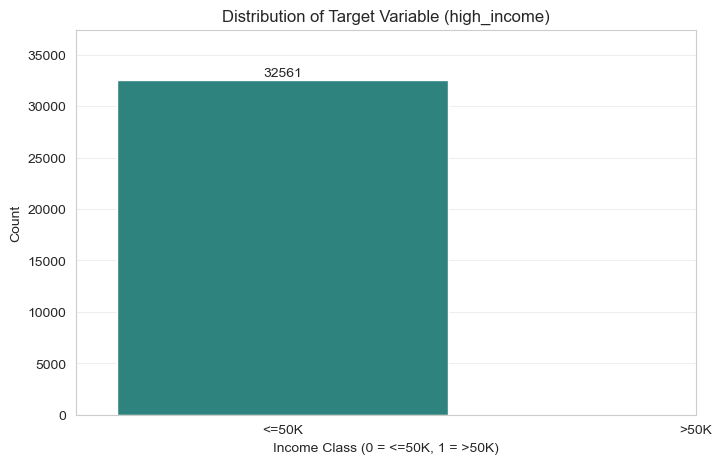

In [110]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='high_income', palette='viridis', hue='high_income', legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Target Variable (high_income)')
plt.xlabel('Income Class (0 = <=50K, 1 = >50K)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['<=50K', '>50K'])
plt.ylim(0, max(counts) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Brief comment (1-2 sentences) on any class imbalance observed

The dataset exhibits a notable class imbalance, with the significant majority of individuals (roughly 76%) earning $50,000 or less, compared to the minority (roughly 24%) earning more. This means your future machine learning models will naturally be exposed to far more examples of the negative class, which can cause them to become biased toward predicting "<=50K" unless properly managed.

### *Hotfix*[¶](#Hotfix)

In [114]:
# =============================================================================
# FRESH START: RELOAD RAW DATA
# =============================================================================
from sklearn.datasets import fetch_openml
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
dataset = fetch_openml(name="adult", version=2, as_frame=True)
df = dataset.data.copy()
df['income'] = dataset.target

# 2. Fix Column Names (Standardize to lowercase with underscores)
df.columns = df.columns.str.lower().str.strip().str.replace('-', '_').str.replace('.', '_')

# 3. Create Target Variable
df['high_income'] = df['income'].astype(str).apply(lambda x: 1 if '>50K' in x else 0)

# 4. Drop original income to prevent leakage
df = df.drop('income', axis=1)

print("Data Reloaded. Current Columns:")
print(df.columns.tolist()) 
# You should see 'workclass', 'education', etc. (NOT workclass_private)

Data Reloaded. Current Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'high_income']


### **Using All Features**

In [116]:
# ===============
# Gemini-generated code for all features
# ===============

from sklearn.preprocessing import StandardScaler
import pandas as pd

def prepare_features(df, algorithm_type='knn'):
    # 1. Identify the target
    y = df['high_income']
    
    # 2. Drop the target and the original text 'income' column if it exists
    X = df.drop(columns=['high_income', 'income'], errors='ignore')
    
    # 3. CONVERT TEXT TO NUMBERS (One-Hot Encoding)
    # This turns 'Private' into a column of 1s and 0s 
    X = pd.get_dummies(X)
    
    # Save feature names for reference
    all_features = X.columns.tolist()
    
    # 4. Scaling (Now that everything is a number, this won't crash)
    if algorithm_type == 'knn':
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        print("Successfully encoded and scaled features.")
    
    return X, y, all_features

In [117]:
# Universal feature set
X_all, y, all_features = prepare_features(df, algorithm_type='knn')

print(f'Successfully created full feature set.')

Successfully encoded and scaled features.
Successfully created full feature set.


## **2. Model Training (30 points)**

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"You have {X_train.shape[1]} features.")

You have 105 features.


### Display the shapes of training and testing sets[¶](#Display-the-shapes-of-training-and-testing-sets)

In [150]:
print("\n" + "="*60)
print("DATASET DIMENSIONS (SHAPES)")
print("="*60)
print(f"X_train shape: {X_train.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


DATASET DIMENSIONS (SHAPES)
X_train shape: (39073, 105)
X_train_scaled shape: (39073, 105)
X_test shape:  (9769, 105)
X_test_scaled shape:  (9769, 105)
y_train shape: (39073,)
y_test shape:  (9769,)


In [152]:
model_results = []
model_results.clear()

### **1. Linear Probability Model (LPM) | Baseline, no regularization**

In [158]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Train the LPM
lpm = LinearRegression()
lpm.fit(X_train, y_train)

# 2. Predict and Calculate Accuracy (Applying the 0.5 Threshold)
y_train_pred_lpm = lpm.predict(X_train)
y_train_pred_class_lpm = (y_train_pred_lpm >= 0.5).astype(int)
lpm_train_acc = accuracy_score(y_train, y_train_pred_class_lpm)

# 3. Extract Coefficients and Intercept
lpm_summary = pd.DataFrame({
    'Feature name': all_features,
    'Coefficient': lpm.coef_
})

# Add Intercept to the table
intercept_row = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [lpm.intercept_]})
lpm_summary = pd.concat([intercept_row, lpm_summary], ignore_index=True)

# 4. Display the results
print("1. LPM (Baseline)")
print("="*80)
print(f"Features in model:             {X_train.shape[1]}")
print(f"Model R-squared (Training):    {lpm.score(X_train, y_train):.4f}")
print(f"Training Accuracy (Threshold): {lpm_train_acc:.4f}")

print("\n" + "="*80)
print("MODEL SUMMARY: COEFFICIENTS")

lpm_summary['Abs_Coef'] = lpm_summary['Coefficient'].abs()
sorted_summary = lpm_summary.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

print(sorted_summary.to_string(index=False))

print("\n" + "="*80)
print("COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)")
for _, row in sorted_summary.iterrows():
    print(f"{row['Feature name']:35s}: {row['Coefficient']:10.4f}")

model_results.append({
    'Model': '1. Baseline LPM',
    'Training Accuracy': lpm_train_acc,
    'Best Hyperparameters': 'N/A (Baseline)'
})

1. LPM (Baseline)
Features in model:             105
Model R-squared (Training):    0.3675
Training Accuracy (Threshold): 0.8415

MODEL SUMMARY: COEFFICIENTS
                             Feature name   Coefficient
                                 sex_Male  2.953255e+12
                               sex_Female  2.953255e+12
                        workclass_Private -1.846609e+12
                               race_White -1.784248e+12
                     relationship_Husband  1.749584e+12
        marital_status_Married-civ-spouse -1.701122e+12
             marital_status_Never-married -1.605379e+12
               relationship_Not-in-family  1.559499e+12
                            education_num -1.516269e+12
                               race_Black -1.492459e+12
                occupation_Prof-specialty  1.331661e+12
                  occupation_Craft-repair  1.326104e+12
               occupation_Exec-managerial  1.323683e+12
                   relationship_Own-child  1.291273e+12
  

### **2. LPM + Lasso | alpha tuned via cross-validation**

In [160]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize LassoCV
lasso_cv = LassoCV(
    alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0], 
    cv=5, 
    max_iter=2000, 
    random_state=42
)

# 2. Fit the model
lasso_cv.fit(X_train_scaled, y_train)

# 3. Extract the best alpha found by Cross-Validation
best_alpha = lasso_cv.alpha_

# 4. Predict and Calculate Accuracy
y_train_pred = lasso_cv.predict(X_train_scaled)
# Convert to 0 or 1 based on the 0.5 threshold
y_train_pred_class = (y_train_pred >= 0.5).astype(int)
# Calculate classification accuracy
lasso_train_acc = accuracy_score(y_train, y_train_pred_class)

# 5. Extract Coefficients and Intercept
lasso_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': lasso_cv.coef_
})

# Add Intercept to the table
intercept_row = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [lasso_cv.intercept_]})
lasso_summary = pd.concat([intercept_row, lasso_summary], ignore_index=True)

# 6. Display the Results
print("LPM + LASSO (L1 Regularization)")
print("="*80)
print(f"Optimal Alpha Selected via CV: {best_alpha}")
print(f"Model R-squared (Training):    {lasso_cv.score(X_train_scaled, y_train):.4f}")
print(f"Training Accuracy (Threshold): {lasso_train_acc:.4f}")

# Count how many features Lasso kept vs eliminated
features_kept = sum(lasso_cv.coef_ != 0)
total_features = len(lasso_cv.coef_)
print(f"Features Kept:                 {features_kept} out of {total_features}")

print("\n" + "="*80)
print("COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)")
lasso_summary['Abs_Coef'] = lasso_summary['Coefficient'].abs()
sorted_lasso = lasso_summary.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

for _, row in sorted_lasso.iterrows():
    status = "(ELIMINATED)" if row['Coefficient'] == 0 and row['Feature name'] != '(Intercept)' else ""
    print(f"{row['Feature name']:35s}: {row['Coefficient']:10.4f} {status}")

model_results.append({
    'Model': '2. LPM + Lasso',
    'Training Accuracy': lasso_train_acc,
    'Best Hyperparameters': f"Alpha: {best_alpha}"
})

LPM + LASSO (L1 Regularization)
Optimal Alpha Selected via CV: 0.001
Model R-squared (Training):    0.3679
Training Accuracy (Threshold): 0.8402
Features Kept:                 77 out of 105

COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)
(Intercept)                        :     0.2393 
marital_status_Married-civ-spouse  :     0.0707 
capital_gain                       :     0.0572 
education_num                      :     0.0555 
relationship_Husband               :     0.0491 
occupation_Exec-managerial         :     0.0473 
relationship_Wife                  :     0.0421 
capital_loss                       :     0.0365 
hours_per_week                     :     0.0326 
age                                :     0.0314 
occupation_Prof-specialty          :     0.0265 
sex_Female                         :    -0.0229 
education_Masters                  :     0.0228 
education_Prof-school              :     0.0186 
workclass_Federal-gov              :     0.0177 
education_Doctorate            

### **3. LPM + Ridge | alpha tuned via cross-validation**

In [166]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize RidgeCV
ridge_cv = RidgeCV(
    alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0], 
    cv=5
)

# 2. Fit the model
ridge_cv.fit(X_train_scaled, y_train)

# 3. Extract the best alpha found
best_ridge_alpha = ridge_cv.alpha_

# 4. Predict and Calculate Accuracy (Applying the 0.5 Threshold)
y_train_pred_ridge = ridge_cv.predict(X_train_scaled)
y_train_pred_class_ridge = (y_train_pred_ridge >= 0.5).astype(int)
ridge_train_acc = accuracy_score(y_train, y_train_pred_class_ridge)

# 5. Extract Coefficients and Intercept
ridge_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': ridge_cv.coef_
})

# Add Intercept to the table
intercept_row_ridge = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [ridge_cv.intercept_]})
ridge_summary = pd.concat([intercept_row_ridge, ridge_summary], ignore_index=True)

# 6. Display the Results
print("LPM + RIDGE (L2 Regularization)")
print("="*80)
print(f"Optimal Alpha Selected via CV: {best_ridge_alpha}")
print(f"Model R-squared (Training):    {ridge_cv.score(X_train_scaled, y_train):.4f}")
print(f"Training Accuracy (Threshold): {ridge_train_acc:.4f}")

print("\n" + "="*80)
print("MODEL SUMMARY: RIDGE COEFFICIENTS")

ridge_summary['Abs_Coef'] = ridge_summary['Coefficient'].abs()
sorted_ridge = ridge_summary.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

print(sorted_ridge.to_string(index=False))

print("\n" + "="*80)
print("COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)")
for _, row in sorted_ridge.iterrows():
    print(f"{row['Feature name']:35s}: {row['Coefficient']:10.4f}")

model_results.append({
    'Model': '3. LPM + Ridge',
    'Training Accuracy': ridge_train_acc,
    'Best Hyperparameters': f"Alpha: {best_ridge_alpha}"
})

LPM + RIDGE (L2 Regularization)
Optimal Alpha Selected via CV: 1000.0
Model R-squared (Training):    0.3683
Training Accuracy (Threshold): 0.8411

MODEL SUMMARY: RIDGE COEFFICIENTS
                             Feature name  Coefficient
                              (Intercept)     0.239270
                             capital_gain     0.056466
        marital_status_Married-civ-spouse     0.044998
               occupation_Exec-managerial     0.042135
                            education_num     0.039653
                        relationship_Wife     0.036793
                             capital_loss     0.036389
                     relationship_Husband     0.035298
                           hours_per_week     0.033073
                                      age     0.031326
             marital_status_Never-married    -0.030068
               relationship_Not-in-family    -0.029687
                        education_Masters     0.025708
                occupation_Prof-specialty     0.0

### **4. LPM + Elastic Net | alpha and l1_ratio tuned via cross-validation**

In [168]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Initialize ElasticNetCV
en_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    alphas=[0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    cv=5, 
    max_iter=2000,
    random_state=42
)

# 2. Fit the model
en_cv.fit(X_train_scaled, y_train)

# 3. Extract the best hyperparameters found by CV
best_en_alpha = en_cv.alpha_
best_en_l1_ratio = en_cv.l1_ratio_

# 4. Predict and Calculate Accuracy (Applying the 0.5 Threshold)
y_train_pred_en = en_cv.predict(X_train_scaled)
y_train_pred_class_en = (y_train_pred_en >= 0.5).astype(int)
en_train_acc = accuracy_score(y_train, y_train_pred_class_en)

# 5. Extract Coefficients and Intercept
en_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': en_cv.coef_
})

# Add Intercept to the table
intercept_row_en = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [en_cv.intercept_]})
en_summary = pd.concat([intercept_row_en, en_summary], ignore_index=True)

# 6. Display the Results
print("LPM + ELASTIC NET (L1 & L2 Regularization)")
print("="*80)
print(f"Optimal Alpha (Strength):      {best_en_alpha}")
print(f"Optimal L1 Ratio (Mix):        {best_en_l1_ratio}")
print(f"Model R-squared (Training):    {en_cv.score(X_train_scaled, y_train):.4f}")
print(f"Training Accuracy (Threshold): {en_train_acc:.4f}")

# Count features
features_kept_en = sum(en_cv.coef_ != 0)
total_features_en = len(en_cv.coef_)
print(f"Features Kept:                 {features_kept_en} out of {total_features_en}")

print("\n" + "="*80)
print("MODEL SUMMARY: ELASTIC NET COEFFICIENTS")

# Sort by absolute value
en_summary['Abs_Coef'] = en_summary['Coefficient'].abs()
sorted_en = en_summary.sort_values(by='Abs_Coef', ascending=False).drop(columns=['Abs_Coef'])

print(sorted_en.to_string(index=False))

print("\n" + "="*80)
print("COEFFICIENTS (ROUNDED TO 4 DECIMAL PLACES)")
for _, row in sorted_en.iterrows():
    status = "(ELIMINATED)" if row['Coefficient'] == 0 and row['Feature name'] != '(Intercept)' else ""
    print(f"{row['Feature name']:35s}: {row['Coefficient']:10.4f} {status}")

model_results.append({
    'Model': '4. LPM + Elastic Net',
    'Training Accuracy': en_train_acc,
    'Best Hyperparameters': f"Alpha: {best_en_alpha}, l1_ratio: {best_en_l1_ratio}"
})

LPM + ELASTIC NET (L1 & L2 Regularization)
Optimal Alpha (Strength):      0.001
Optimal L1 Ratio (Mix):        0.5
Model R-squared (Training):    0.3682
Training Accuracy (Threshold): 0.8408
Features Kept:                 92 out of 105

MODEL SUMMARY: ELASTIC NET COEFFICIENTS
                             Feature name  Coefficient
                              (Intercept)     0.239270
        marital_status_Married-civ-spouse     0.063305
                             capital_gain     0.057417
                     relationship_Husband     0.053799
                            education_num     0.053634
               occupation_Exec-managerial     0.048028
                        relationship_Wife     0.044863
                             capital_loss     0.036793
                           hours_per_week     0.033057
                                      age     0.031753
                occupation_Prof-specialty     0.027294
                        education_Masters     0.023889
        

### **5. Logistic Regression | Baseline, no regularization (penalty=None)**

In [170]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Initialize Logit (penalty=None)
log_reg = LogisticRegression(penalty=None, max_iter=2000, random_state=42)

# 2. Fit the model using the FULL, SCALED feature set
log_reg.fit(X_train_scaled, y_train)

# 3. Calculate Training Accuracy directly
log_train_acc = log_reg.score(X_train_scaled, y_train)

# 4. Extract Coefficients and Intercept
log_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': log_reg.coef_[0]
})

# Add the Intercept
log_intercept = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [log_reg.intercept_[0]]})
log_summary = pd.concat([log_intercept, log_summary], ignore_index=True)

# 5. Display Model Summary
print("LOGISTIC REGRESSION (Baseline, No Regularization)")
print("="*80)
print(f"Number of features used: {X_train_scaled.shape[1]}")
print(f"Training Accuracy:       {log_train_acc:.4f}")
print(f"Intercept:               {log_reg.intercept_[0]:.4f}")

print("\n" + "="*80)
print(f"{'Feature Name':<35} | {'Coefficient':>12}")
print("-" * 80)

# Sort by absolute coefficient value to show importance
log_summary['abs_val'] = log_summary['Coefficient'].abs()
sorted_log = log_summary.sort_values('abs_val', ascending=False).drop(columns=['abs_val'])

for _, row in sorted_log.iterrows():
    print(f"{row['Feature name']:<35} | {row['Coefficient']:>12.4f}")

# 6. Odds Ratios
print("\n" + "="*80)
print("ODDS RATIOS (exp(coef))")
print("="*80)
for _, row in sorted_log.iterrows():
    if row['Feature name'] != '(Intercept)':
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature name']:<35} | {odds_ratio:>12.4f}")

model_results.append({
    'Model': '5. Logistic Regression (Baseline)',
    'Training Accuracy': log_train_acc,
    'Best Hyperparameters': 'N/A (Baseline)'
})

LOGISTIC REGRESSION (Baseline, No Regularization)
Number of features used: 105
Training Accuracy:       0.8538
Intercept:               -2.0928

Feature Name                        |  Coefficient
--------------------------------------------------------------------------------
capital_gain                        |       2.2729
(Intercept)                         |      -2.0928
marital_status_Married-civ-spouse   |       0.8556
marital_status_Never-married        |      -0.5987
hours_per_week                      |       0.3516
education_num                       |       0.3516
age                                 |       0.3373
occupation_Exec-managerial          |       0.3299
marital_status_Divorced             |      -0.2717
capital_loss                        |       0.2655
workclass_Private                   |       0.2555
occupation_Prof-specialty           |       0.2338
relationship_Not-in-family          |       0.2141
occupation_Other-service            |      -0.2108
education

### **6. Logistic Regression + Lasso | C tuned via cross-validation, penalty='l1'**

In [172]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV

# 1. Initialize LogisticRegressionCV
log_l1_cv = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
    cv=5, 
    penalty='l1', 
    solver='saga', 
    max_iter=2000, 
    random_state=42,
    n_jobs=-1
)

# 2. Fit the model using the FULL, SCALED feature set
log_l1_cv.fit(X_train_scaled, y_train)

# 3. Extract the best C found by Cross-Validation
best_C = log_l1_cv.C_[0]

# 4. Calculate Training Accuracy directly
log_l1_train_acc = log_l1_cv.score(X_train_scaled, y_train)

# 5. Extract Coefficients and Intercept
log_l1_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': log_l1_cv.coef_[0]
})

# Add the Intercept
log_l1_intercept = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [log_l1_cv.intercept_[0]]})
log_l1_summary = pd.concat([log_l1_intercept, log_l1_summary], ignore_index=True)

# 6. Display Model Summary
print("LOGISTIC REGRESSION + LASSO (L1 Regularization)")
print("="*80)
print(f"Optimal C Selected via CV: {best_C}")
print(f"Training Accuracy:         {log_l1_train_acc:.4f}")

# Count how many features were kept vs eliminated by L1
features_kept = sum(log_l1_cv.coef_[0] != 0)
total_features = len(log_l1_cv.coef_[0])
print(f"Features Kept:             {features_kept} out of {total_features}")
print(f"Features Zeroed Out:       {total_features - features_kept}")

print("\n" + "="*80)
print(f"{'Feature Name':<35} | {'Coefficient':>12}")
print("-" * 80)

# Sort by absolute coefficient value
log_l1_summary['abs_val'] = log_l1_summary['Coefficient'].abs()
sorted_log_l1 = log_l1_summary.sort_values('abs_val', ascending=False).drop(columns=['abs_val'])

for _, row in sorted_log_l1.iterrows():
    status = " (ELIMINATED)" if row['Coefficient'] == 0 and row['Feature name'] != '(Intercept)' else ""
    print(f"{row['Feature name']:<35} | {row['Coefficient']:>12.4f}{status}")

# 7. Odds Ratios
print("\n" + "="*80)
print("ODDS RATIOS (exp(coef)) FOR RETAINED FEATURES")
print("="*80)
for _, row in sorted_log_l1.iterrows():
    if row['Feature name'] != '(Intercept)' and row['Coefficient'] != 0:
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature name']:<35} | {odds_ratio:>12.4f}")

model_results.append({
    'Model': '6. Logistic Regression + Lasso (L1)',
    'Training Accuracy': log_l1_train_acc,
    'Best Hyperparameters': f"C: {best_C}"
})

LOGISTIC REGRESSION + LASSO (L1 Regularization)
Optimal C Selected via CV: 0.1
Training Accuracy:         0.8532
Features Kept:             94 out of 105
Features Zeroed Out:       11

Feature Name                        |  Coefficient
--------------------------------------------------------------------------------
capital_gain                        |       2.2061
(Intercept)                         |      -2.0526
marital_status_Married-civ-spouse   |       0.9995
education_num                       |       0.6880
hours_per_week                      |       0.3498
age                                 |       0.3308
occupation_Exec-managerial          |       0.3116
capital_loss                        |       0.2623
marital_status_Never-married        |      -0.2392
relationship_Own-child              |      -0.2380
relationship_Wife                   |       0.2374
workclass_Private                   |       0.2309
occupation_Other-service            |      -0.2184
occupation_Prof-spec

### **7. Logistic Regression + Ridge | C tuned via cross-validation, penalty='l2'**

In [174]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV

# 1. Initialize LogisticRegressionCV
log_l2_cv = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
    cv=5, 
    penalty='l2', 
    solver='lbfgs', 
    max_iter=2000, 
    random_state=42,
    n_jobs=-1
)

# 2. Fit the model using the FULL, SCALED feature set
log_l2_cv.fit(X_train_scaled, y_train)

# 3. Extract the best C found by Cross-Validation
best_C_l2 = log_l2_cv.C_[0]

# 4. Calculate Training Accuracy directly
log_l2_train_acc = log_l2_cv.score(X_train_scaled, y_train)

# 5. Extract Coefficients and Intercept
log_l2_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': log_l2_cv.coef_[0]
})

# Add the Intercept
log_l2_intercept = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [log_l2_cv.intercept_[0]]})
log_l2_summary = pd.concat([log_l2_intercept, log_l2_summary], ignore_index=True)

# 6. Display Model Summary
print("LOGISTIC REGRESSION + RIDGE (L2 Regularization)")
print("="*80)
print(f"Optimal C Selected via CV: {best_C_l2}")
print(f"Training Accuracy:         {log_l2_train_acc:.4f}")

# Verify that L2 keeps all features
features_kept_l2 = sum(log_l2_cv.coef_[0] != 0)
total_features_l2 = len(log_l2_cv.coef_[0])
print(f"Features Kept:             {features_kept_l2} out of {total_features_l2}")

print("\n" + "="*80)
print(f"{'Feature Name':<35} | {'Coefficient':>12}")
print("-" * 80)

# Sort by absolute coefficient value
log_l2_summary['abs_val'] = log_l2_summary['Coefficient'].abs()
sorted_log_l2 = log_l2_summary.sort_values('abs_val', ascending=False).drop(columns=['abs_val'])

for _, row in sorted_log_l2.iterrows():
    print(f"{row['Feature name']:<35} | {row['Coefficient']:>12.4f}")

# 7. Odds Ratios
print("\n" + "="*80)
print("ODDS RATIOS (exp(coef))")
print("="*80)
for _, row in sorted_log_l2.iterrows():
    if row['Feature name'] != '(Intercept)':
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature name']:<35} | {odds_ratio:>12.4f}")

model_results.append({
    'Model': '7. Logistic Regression + Ridge (L2)',
    'Training Accuracy': log_l2_train_acc,
    'Best Hyperparameters': f"C: {best_C_l2}"
})

LOGISTIC REGRESSION + RIDGE (L2 Regularization)
Optimal C Selected via CV: 10.0
Training Accuracy:         0.8537
Features Kept:             105 out of 105

Feature Name                        |  Coefficient
--------------------------------------------------------------------------------
capital_gain                        |       2.2841
(Intercept)                         |      -2.0905
marital_status_Married-civ-spouse   |       0.8209
marital_status_Never-married        |      -0.5800
hours_per_week                      |       0.3520
education_num                       |       0.3510
age                                 |       0.3372
occupation_Exec-managerial          |       0.3306
capital_loss                        |       0.2657
marital_status_Divorced             |      -0.2566
workclass_Private                   |       0.2561
occupation_Prof-specialty           |       0.2347
relationship_Own-child              |      -0.2107
occupation_Other-service            |      -0.21

### **8. Logistic Regression + Elastic Net | C and l1_ratio tuned via cross-validation**

In [176]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV

# 1. Initialize LogisticRegressionCV
log_en_cv = LogisticRegressionCV(
    Cs=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
    l1_ratios=[0.1, 0.5, 0.9],
    cv=3, 
    penalty='elasticnet', 
    solver='saga', 
    tol=0.01,
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

# 2. Fit the model using the FULL, SCALED feature set
log_en_cv.fit(X_train_scaled, y_train)

# 3. Extract the best hyperparameters found by Cross-Validation
best_C_en = log_en_cv.C_[0]
best_l1_ratio_en = log_en_cv.l1_ratio_[0]

# 4. Calculate Training Accuracy directly
log_en_train_acc = log_en_cv.score(X_train_scaled, y_train)

# 5. Extract Coefficients and Intercept
log_en_summary = pd.DataFrame({
    'Feature name': all_features, 
    'Coefficient': log_en_cv.coef_[0]
})

# Add the Intercept
log_en_intercept = pd.DataFrame({'Feature name': ['(Intercept)'], 'Coefficient': [log_en_cv.intercept_[0]]})
log_en_summary = pd.concat([log_en_intercept, log_en_summary], ignore_index=True)

# 6. Display Model Summary
print("LOGISTIC REGRESSION + ELASTIC NET")
print("="*80)
print(f"Optimal C (Strength):      {best_C_en}")
print(f"Optimal L1 Ratio (Mix):    {best_l1_ratio_en}")
print(f"Training Accuracy:         {log_en_train_acc:.4f}")

# Count features
features_kept_en = sum(log_en_cv.coef_[0] != 0)
total_features_en = len(log_en_cv.coef_[0])
print(f"Features Kept:             {features_kept_en} out of {total_features_en}")

print("\n" + "="*80)
print(f"{'Feature Name':<35} | {'Coefficient':>12}")
print("-" * 80)

# Sort by absolute coefficient value
log_en_summary['abs_val'] = log_en_summary['Coefficient'].abs()
sorted_log_en = log_en_summary.sort_values('abs_val', ascending=False).drop(columns=['abs_val'])

for _, row in sorted_log_en.iterrows():
    status = " (ELIMINATED)" if row['Coefficient'] == 0 and row['Feature name'] != '(Intercept)' else ""
    print(f"{row['Feature name']:<35} | {row['Coefficient']:>12.4f}{status}")

# 7. Odds Ratios
print("\n" + "="*80)
print("ODDS RATIOS (exp(coef)) FOR RETAINED FEATURES")
print("="*80)
for _, row in sorted_log_en.iterrows():
    if row['Feature name'] != '(Intercept)' and row['Coefficient'] != 0:
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature name']:<35} | {odds_ratio:>12.4f}")

model_results.append({
    'Model': '8. Logistic Regression + Elastic Net',
    'Training Accuracy': log_en_train_acc,
    'Best Hyperparameters': f"C: {best_C_en}, l1_ratio: {best_l1_ratio_en}"
})

LOGISTIC REGRESSION + ELASTIC NET
Optimal C (Strength):      0.1
Optimal L1 Ratio (Mix):    1.0
Training Accuracy:         0.8532
Features Kept:             94 out of 105

Feature Name                        |  Coefficient
--------------------------------------------------------------------------------
capital_gain                        |       2.2061
(Intercept)                         |      -2.0526
marital_status_Married-civ-spouse   |       0.9995
education_num                       |       0.6880
hours_per_week                      |       0.3498
age                                 |       0.3308
occupation_Exec-managerial          |       0.3116
capital_loss                        |       0.2623
marital_status_Never-married        |      -0.2392
relationship_Own-child              |      -0.2380
relationship_Wife                   |       0.2374
workclass_Private                   |       0.2309
occupation_Other-service            |      -0.2184
occupation_Prof-specialty        

### **9. Random Forest | Hyperparameter autotuning via GridSearchCV or RandomizedSearchCV**

MODEL TRAINING - RANDOM FOREST (Hyperparameter Tuning)
Tuning Random Forest hyperparameters... please wait.
Fitting 3 folds for each of 6 candidates, totalling 18 fits

RANDOM FOREST RESULTS
Best Hyperparameters Found:
  • n_estimators: 100
  • min_samples_split: 5
  • min_samples_leaf: 4
  • max_features: sqrt
  • max_depth: 30

• Training Accuracy: 0.8786
• Test Accuracy:     0.8684

TOP 15 FEATURE IMPORTANCES:
----------------------------------------
                          Feature  Importance
                     capital_gain    0.148119
marital_status_Married-civ-spouse    0.114769
             relationship_Husband    0.109394
                    education_num    0.092673
                              age    0.077062
                   hours_per_week    0.048116
     marital_status_Never-married    0.047285
                     capital_loss    0.040763
       occupation_Exec-managerial    0.029227
                           fnlwgt    0.028299
        occupation_Prof-specialty   

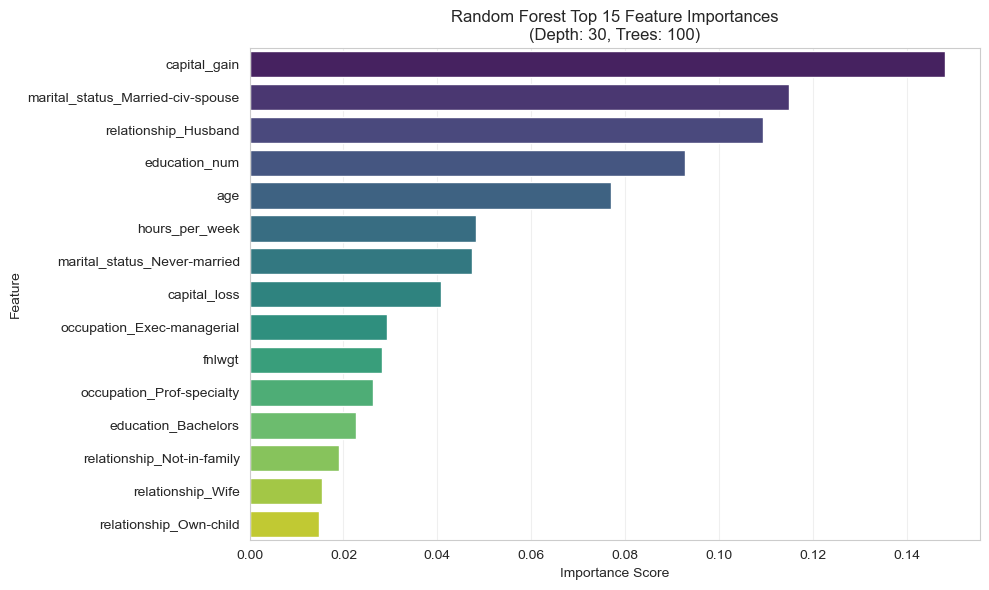

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

print("MODEL TRAINING - RANDOM FOREST (Hyperparameter Tuning)")
print("=" * 80)

# ===============
# Gemini-aided for faster processing
# ===============

# 1. Faster parameter grid
param_dist = {
    'n_estimators': [100],               # Fewer trees during tuning
    'max_depth': [10, 20, 30],           # Cap the depth
    'max_features': ['sqrt'],            # 'None' (all features) is very slow
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4]              # Larger leaves = faster trees
}

# 2. Parallelize the base model and the search
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=5,                            # Reduce iterations for speed
    cv=3, 
    random_state=42, 
    n_jobs=-1,  
    verbose=1   
)

# 3. Setup RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=3, 
    random_state=42, 
    n_jobs=-1,  
    verbose=1   
)

# 4. Fit the Search
print("Tuning Random Forest hyperparameters... please wait.")
rf_random.fit(X_train, y_train)

# 5. Extract the BEST model found by the search
best_rf = rf_random.best_estimator_
best_rf_params = rf_random.best_params_

# 6. Calculate Accuracy
rf_train_acc = best_rf.score(X_train, y_train)
rf_test_acc = best_rf.score(X_test, y_test)

print("\n" + "=" * 80)
print("RANDOM FOREST RESULTS")
print("=" * 80)
print(f"Best Hyperparameters Found:")
for param, value in best_rf_params.items():
    print(f"  • {param}: {value}")

print(f"\n• Training Accuracy: {rf_train_acc:.4f}")
print(f"• Test Accuracy:     {rf_test_acc:.4f}\n")

# 7. Extract Feature Importances from the BEST model
rf_importances = best_rf.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print("TOP 15 FEATURE IMPORTANCES:")
print("-" * 40)
print(rf_importance_df.head(15).to_string(index=False))

# 8. Create visualization of Top 15 Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(15), palette='viridis')

plt.title(f'Random Forest Top 15 Feature Importances\n(Depth: {best_rf_params["max_depth"]}, Trees: {best_rf_params["n_estimators"]})')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

rf_param_str = f"Trees: {best_rf_params['n_estimators']}, Depth: {best_rf_params['max_depth']}, Max Features: {best_rf_params['max_features']}"

model_results.append({
    'Model': '9. Random Forest',
    'Training Accuracy': rf_train_acc,
    'Best Hyperparameters': rf_param_str
})

### **10. Gradient Boosting | Hyperparameter autotuning via GridSearchCV or RandomizedSearchCV**


MODEL TRAINING - GRADIENT BOOSTING (Hyperparameter Tuning)
Tuning Gradient Boosting hyperparameters... please wait.
Fitting 3 folds for each of 5 candidates, totalling 15 fits

GRADIENT BOOSTING RESULTS
Best Hyperparameters Found:
  • subsample: 0.8
  • n_estimators: 200
  • max_depth: 5
  • learning_rate: 0.05

• Training Accuracy: 0.8819
• Test Accuracy:     0.8752

TOP 15 FEATURE IMPORTANCES:
----------------------------------------
                          Feature  Importance
marital_status_Married-civ-spouse    0.366124
                     capital_gain    0.190134
                    education_num    0.185637
                     capital_loss    0.067262
                              age    0.055324
                   hours_per_week    0.035381
       occupation_Exec-managerial    0.017714
                           fnlwgt    0.013587
        occupation_Prof-specialty    0.007268
         occupation_Other-service    0.006252
       workclass_Self-emp-not-inc    0.005534
       

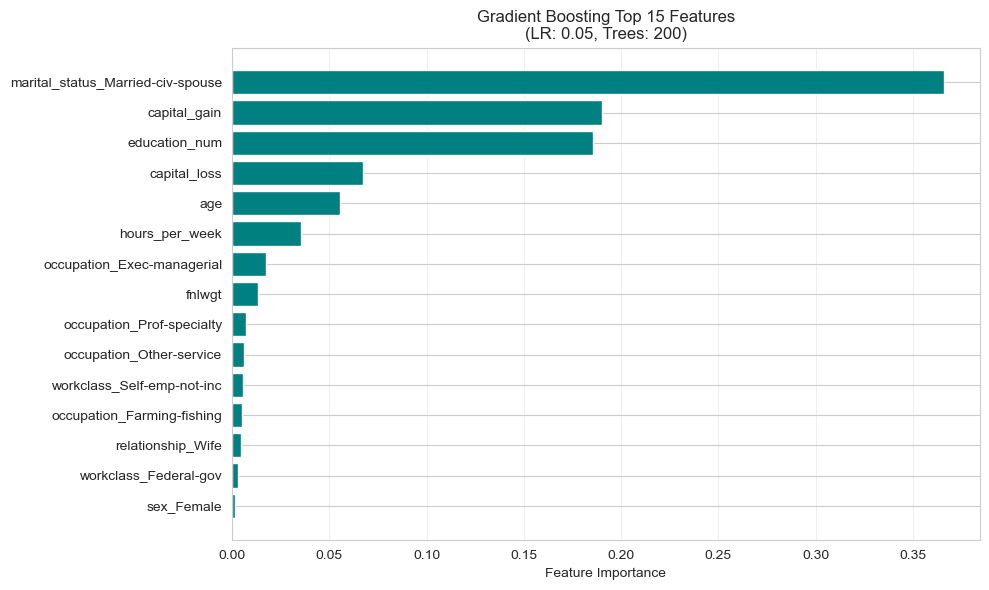


Most important feature:  marital_status_Married-civ-spouse
Least important feature: occupation_Priv-house-serv


In [182]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "=" * 80)
print("MODEL TRAINING - GRADIENT BOOSTING (Hyperparameter Tuning)")
print("=" * 80)

gb_base = GradientBoostingClassifier(random_state=42)

===============
# Gemini-aided for faster processing
# ===============

# 1. Focused parameter grid
param_dist_gb = {
    'n_estimators': [100, 200],         # High tree counts are slow; keep it moderate
    'learning_rate': [0.05, 0.1],      # Focus on the most common effective rates
    'max_depth': [3, 4, 5],            # GB works best with shallow trees (weak learners)
    'subsample': [0.8]                 # Subsampling speeds up each tree build
}

# 2. Setup RandomizedSearchCV
gb_random = RandomizedSearchCV(
    estimator=gb_base, 
    param_distributions=param_dist_gb, 
    n_iter=5,                          # Fewer iterations for the search
    cv=3, 
    random_state=42, 
    n_jobs=-1,                         # Still use parallel processing for the CV folds
    verbose=1
)


# 4. Fit the Search
print("Tuning Gradient Boosting hyperparameters... please wait.")
gb_random.fit(X_train, y_train)

# 5. Extract the BEST model found
best_gb = gb_random.best_estimator_
best_gb_params = gb_random.best_params_

# 6. Calculate Accuracy
gb_train_acc = best_gb.score(X_train, y_train)
gb_test_acc = best_gb.score(X_test, y_test)

print("\n" + "=" * 80)
print("GRADIENT BOOSTING RESULTS")
print("=" * 80)
print(f"Best Hyperparameters Found:")
for param, value in best_gb_params.items():
    print(f"  • {param}: {value}")

print(f"\n• Training Accuracy: {gb_train_acc:.4f}")
print(f"• Test Accuracy:     {gb_test_acc:.4f}\n")

# 7. Extract Feature Importances using the full dataset's columns
gb_importances = best_gb.feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': gb_importances
}).sort_values('Importance', ascending=False)

print("TOP 15 FEATURE IMPORTANCES:")
print("-" * 40)
print(importance_df.head(15).to_string(index=False))

# 8. Plot Top 15 Feature Importances
plt.figure(figsize=(10, 6))

top_15_df = importance_df.head(15)
plt.barh(range(len(top_15_df)), top_15_df['Importance'], color='teal')
plt.yticks(range(len(top_15_df)), top_15_df['Feature'])
plt.xlabel('Feature Importance')

plt.title(f'Gradient Boosting Top 15 Features\n(LR: {best_gb_params["learning_rate"]}, Trees: {best_gb_params["n_estimators"]})')
plt.gca().invert_yaxis() # Put the most important at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMost important feature:  {importance_df.iloc[0]['Feature']}")
print(f"Least important feature: {importance_df.iloc[-1]['Feature']}")

gb_param_str = f"Trees: {best_gb_params['n_estimators']}, Depth: {best_gb_params['max_depth']}, LR: {best_gb_params['learning_rate']}"

model_results.append({
    'Model': '10. Gradient Boosting',
    'Training Accuracy': gb_train_acc,
    'Best Hyperparameters': gb_param_str
})

### **A summary table at the end listing all 10 models, their training accuracy, and key hyperparameters**

In [184]:
print("\n" + "=" * 100)
print("FINAL MODEL COMPARISON SUMMARY: TRAINING ACCURACY & HYPERPARAMETERS")
print("=" * 100)

summary_df = pd.DataFrame(model_results)

summary_df['Training Accuracy'] = summary_df['Training Accuracy'].apply(lambda x: f"{x:.4f}")

pd.set_option('display.max_colwidth', None)

print(summary_df.to_string(index=False))

pd.reset_option('display.max_colwidth')


FINAL MODEL COMPARISON SUMMARY: TRAINING ACCURACY & HYPERPARAMETERS
                               Model Training Accuracy                      Best Hyperparameters
                     1. Baseline LPM            0.8415                            N/A (Baseline)
                      2. LPM + Lasso            0.8402                              Alpha: 0.001
                      3. LPM + Ridge            0.8411                             Alpha: 1000.0
                4. LPM + Elastic Net            0.8408               Alpha: 0.001, l1_ratio: 0.5
   5. Logistic Regression (Baseline)            0.8538                            N/A (Baseline)
 6. Logistic Regression + Lasso (L1)            0.8532                                    C: 0.1
 7. Logistic Regression + Ridge (L2)            0.8537                                   C: 10.0
8. Logistic Regression + Elastic Net            0.8532                     C: 0.1, l1_ratio: 1.0
                    9. Random Forest            0.8786 Tre

## **3. Feature Importance Analysis (15 points)**

### **a) Create a table showing the top 7 features for each of the 8 models, side by side. (5 points)**

In [190]:
import pandas as pd

def get_top_7_linear(df):
    temp_df = df.copy()
    temp_df = temp_df[temp_df['Feature name'] != '(Intercept)']
    temp_df['abs_coef'] = temp_df['Coefficient'].abs()
    temp_df = temp_df.sort_values(by='abs_coef', ascending=False)
    return temp_df['Feature name'].head(7).tolist()

# 2. Helper function for Tree Models (Sorts by Importance)
def get_top_7_tree(df):

    temp_df = df.sort_values(by='Importance', ascending=False)
    return temp_df['Feature'].head(7).tolist()

# 3. Extract the top 7 lists for each model 
m2_top7 = get_top_7_linear(lasso_summary)       # Model 2: LPM Lasso
m3_top7 = get_top_7_linear(ridge_summary)       # Model 3: LPM Ridge
m4_top7 = get_top_7_linear(en_summary)       # Model 4: LPM Elastic Net

m6_top7 = get_top_7_linear(log_l1_summary)       # Model 6: Logit Lasso
m7_top7 = get_top_7_linear(log_l2_summary)       # Model 7: Logit Ridge
m8_top7 = get_top_7_linear(log_en_summary)       # Model 8: Logit Elastic Net

m9_top7 = get_top_7_tree(rf_importance_df)       # Model 9: Random Forest
m10_top7 = get_top_7_tree(importance_df)         # Model 10: Gradient Boosting

# 4. Build the final Summary Dictionary
top_7_data = {
    'Rank': [1, 2, 3, 4, 5, 6, 7],
    'Model 2 (LPM Lasso)': m2_top7,
    'Model 3 (LPM Ridge)': m3_top7,
    'Model 4 (LPM Elastic Net)': m4_top7,
    'Model 6 (Logit Lasso)': m6_top7,
    'Model 7 (Logit Ridge)': m7_top7,
    'Model 8 (Logit Elastic Net)': m8_top7,
    'Model 9 (Random Forest)': m9_top7,
    'Model 10 (Gradient Boosting)': m10_top7
}

top_7_df = pd.DataFrame(top_7_data)

display(top_7_df.style.hide(axis="index"))

# from IPython.display import display

# print("\n" + "="*100)
# print("TOP 7 MOST IMPORTANT FEATURES BY MODEL")
# print("="*100)

# display(top_7_data.style.hide(axis="index"))

Rank,Model 2 (LPM Lasso),Model 3 (LPM Ridge),Model 4 (LPM Elastic Net),Model 6 (Logit Lasso),Model 7 (Logit Ridge),Model 8 (Logit Elastic Net),Model 9 (Random Forest),Model 10 (Gradient Boosting)
1,marital_status_Married-civ-spouse,capital_gain,marital_status_Married-civ-spouse,capital_gain,capital_gain,capital_gain,capital_gain,marital_status_Married-civ-spouse
2,capital_gain,marital_status_Married-civ-spouse,capital_gain,marital_status_Married-civ-spouse,marital_status_Married-civ-spouse,marital_status_Married-civ-spouse,marital_status_Married-civ-spouse,capital_gain
3,education_num,occupation_Exec-managerial,relationship_Husband,education_num,marital_status_Never-married,education_num,relationship_Husband,education_num
4,relationship_Husband,education_num,education_num,hours_per_week,hours_per_week,hours_per_week,education_num,capital_loss
5,occupation_Exec-managerial,relationship_Wife,occupation_Exec-managerial,age,education_num,age,age,age
6,relationship_Wife,capital_loss,relationship_Wife,occupation_Exec-managerial,age,occupation_Exec-managerial,hours_per_week,hours_per_week
7,capital_loss,relationship_Husband,capital_loss,capital_loss,occupation_Exec-managerial,capital_loss,marital_status_Never-married,occupation_Exec-managerial


### **b) Answer the following in 3–4 sentences: (10 points)**

- Which features appear consistently in the top 7 across most models?
> capital_gain and marital_status_Married-civ-spouse appear in the Top 2 for almost every single model.

- Are there any features that only appear important in certain models? What might explain this?
> Yes. The LPMs rely heavily on specific family roles like being a husband or a wife, while the Logit, and tree models prioritize continuous number features like age and hours worked per week. This happens because tree-based algorithms  easily find hidden patterns by repeatedly slicing wide ranges of numbers into smaller groups. On the other hand, simple linear models  prefer distinct "yes or no" categories because belonging to a specific group creates a single, massive jump in their straight-line equations.

- What does consistency (or inconsistency) across models tell us about the usefulness of a feature?
> When a feature is consistent across all models, it tells us that the feature is a highly reliable predictor. On the flip side, inconsistency tells us that a feature's usefulness is conditional. A feature that jumps around in rankings might only be helpful when combined with other specific details that only certain advanced algorithms can see.

## **4. Model Performance Evaluation (50 points)**

### **a) Confusion Matrices — All 10 Models (10 points)**

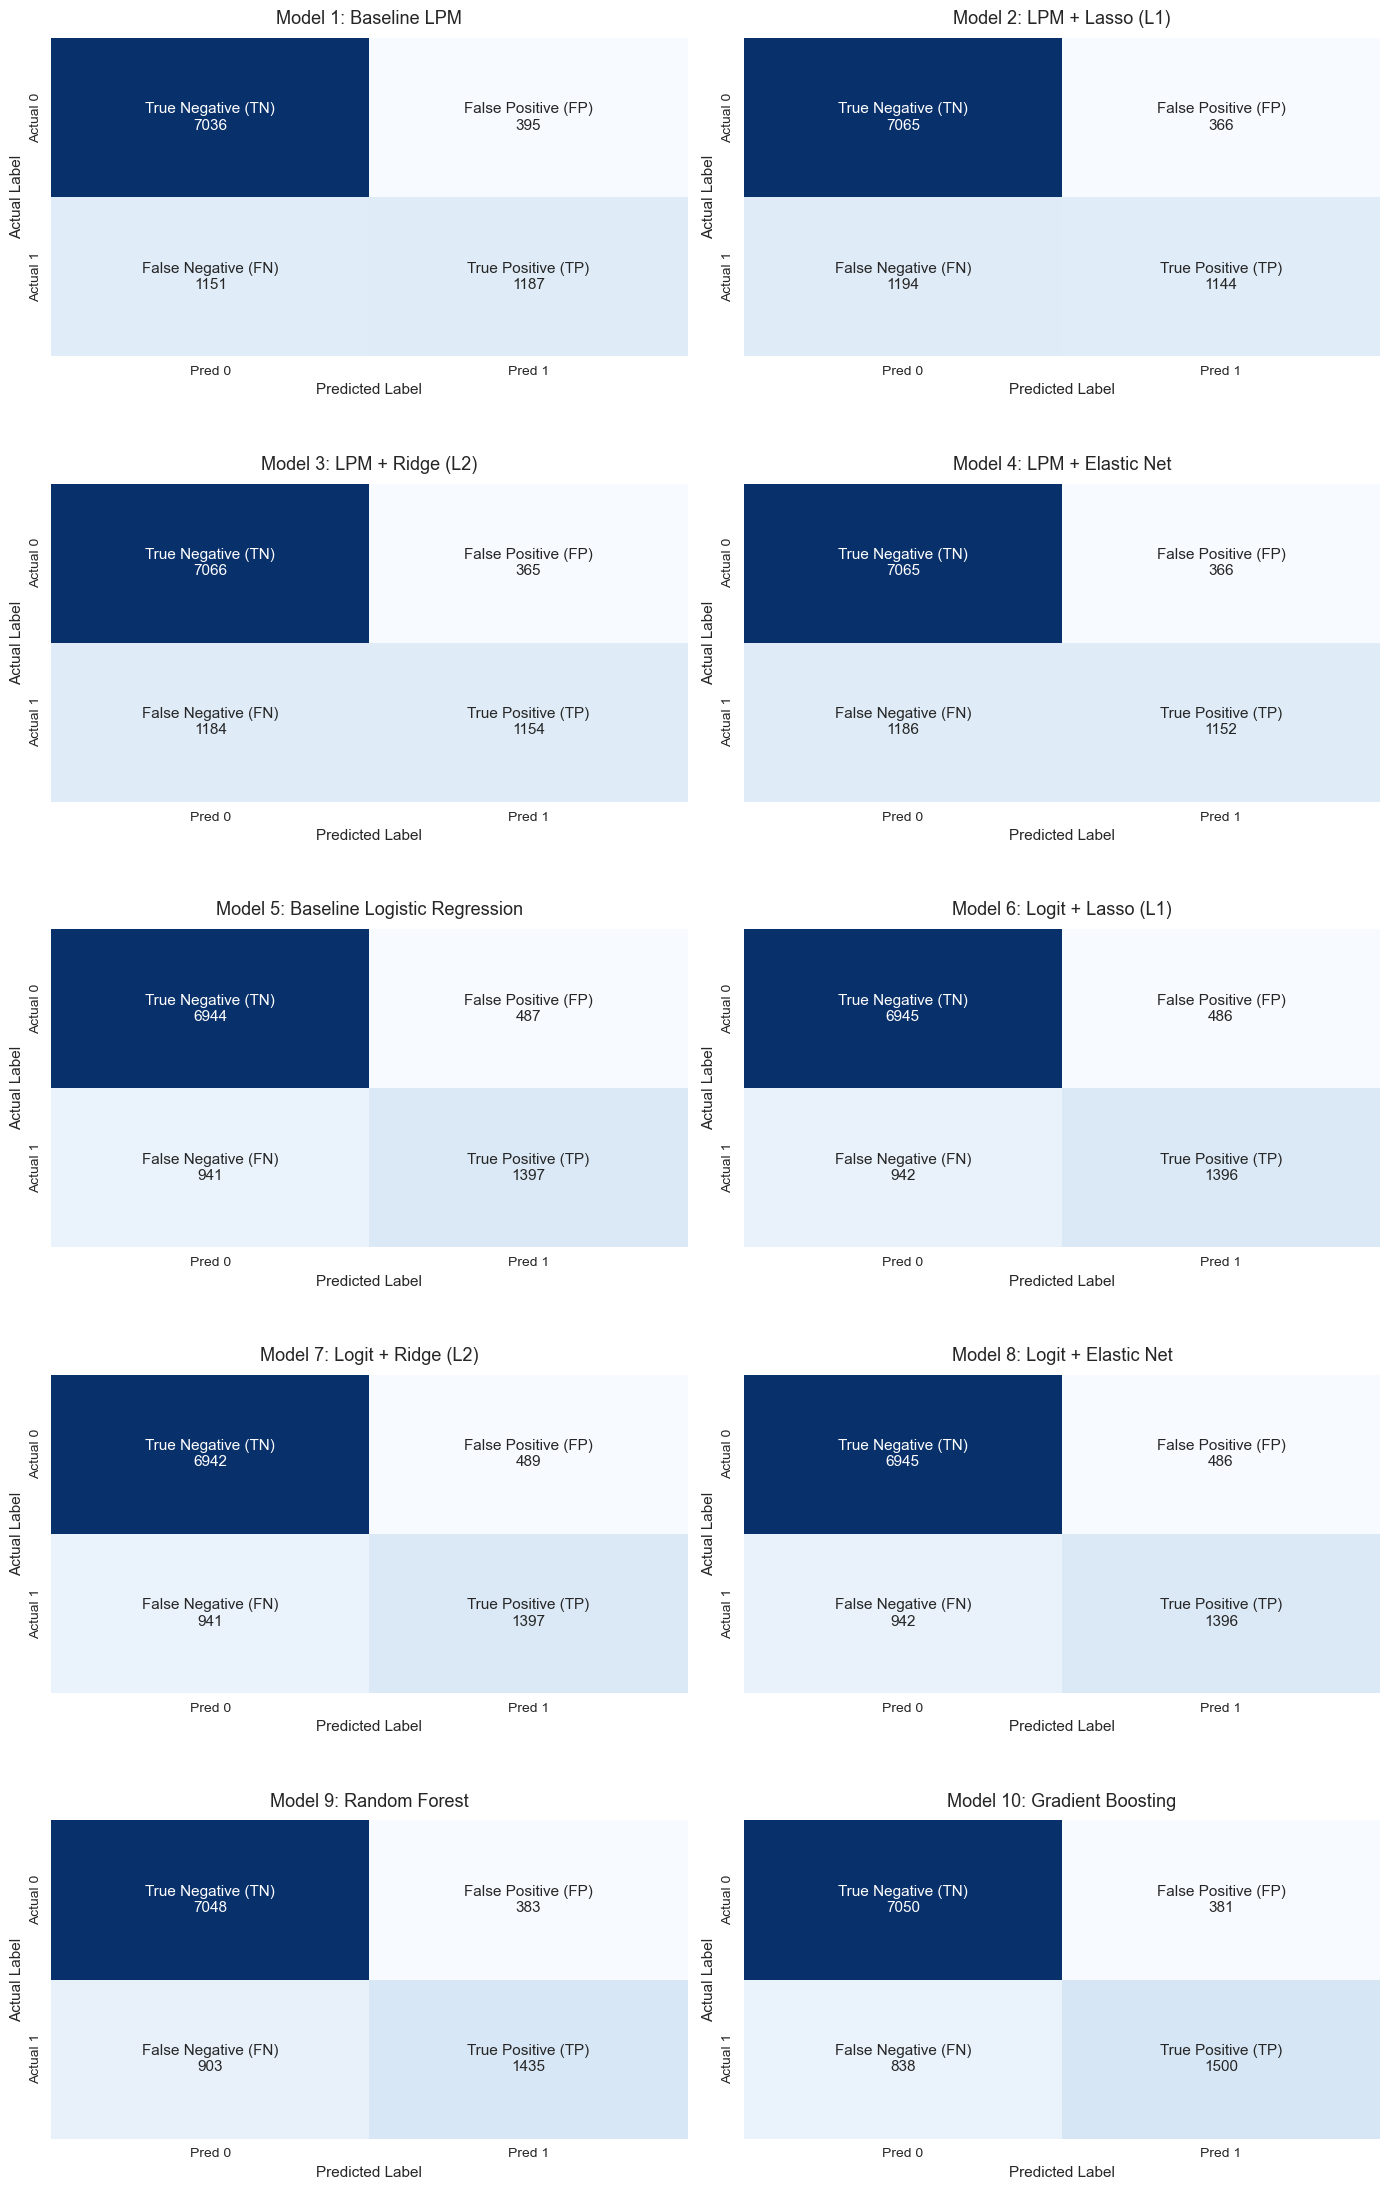

In [195]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()

# ===============
# Gemini-aided for better formatting
# ===============

def plot_custom_confusion_matrix(y_true, y_pred, model_name, ax):
    cm = confusion_matrix(y_true, y_pred)
    
    labels = np.array([
        [f"True Negative (TN)\n{cm[0, 0]}", f"False Positive (FP)\n{cm[0, 1]}"],
        [f"False Negative (FN)\n{cm[1, 0]}", f"True Positive (TP)\n{cm[1, 1]}"]
    ])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
                xticklabels=['Pred 0', 'Pred 1'], 
                yticklabels=['Actual 0', 'Actual 1'],
                annot_kws={"size": 11}, ax=ax)
    
    ax.set_title(f"{model_name}", fontsize=13, pad=10)
    ax.set_ylabel('Actual Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)


# =========================================================
# MODELS 1-4: Linear Probability Models
# =========================================================

y_pred_m1 = (lpm.predict(X_test) >= 0.5).astype(int)
plot_custom_confusion_matrix(y_test, y_pred_m1, "Model 1: Baseline LPM", ax=axes[0])

y_pred_m2 = (lasso_cv.predict(X_test_scaled) >= 0.5).astype(int)
plot_custom_confusion_matrix(y_test, y_pred_m2, "Model 2: LPM + Lasso (L1)", ax=axes[1])

y_pred_m3 = (ridge_cv.predict(X_test_scaled) >= 0.5).astype(int)
plot_custom_confusion_matrix(y_test, y_pred_m3, "Model 3: LPM + Ridge (L2)", ax=axes[2])

y_pred_m4 = (en_cv.predict(X_test_scaled) >= 0.5).astype(int)
plot_custom_confusion_matrix(y_test, y_pred_m4, "Model 4: LPM + Elastic Net", ax=axes[3])


# =========================================================
# MODELS 5-8: Logistic Regression Models
# =========================================================

y_pred_m5 = log_reg.predict(X_test_scaled) 
plot_custom_confusion_matrix(y_test, y_pred_m5, "Model 5: Baseline Logistic Regression", ax=axes[4])

y_pred_m6 = log_l1_cv.predict(X_test_scaled)
plot_custom_confusion_matrix(y_test, y_pred_m6, "Model 6: Logit + Lasso (L1)", ax=axes[5])

y_pred_m7 = log_l2_cv.predict(X_test_scaled)
plot_custom_confusion_matrix(y_test, y_pred_m7, "Model 7: Logit + Ridge (L2)", ax=axes[6])

y_pred_m8 = log_en_cv.predict(X_test_scaled)
plot_custom_confusion_matrix(y_test, y_pred_m8, "Model 8: Logit + Elastic Net", ax=axes[7])


# =========================================================
# MODELS 9-10: Tree-Based Models
# =========================================================

y_pred_m9 = best_rf.predict(X_test)
plot_custom_confusion_matrix(y_test, y_pred_m9, "Model 9: Random Forest", ax=axes[8])

y_pred_m10 = best_gb.predict(X_test)
plot_custom_confusion_matrix(y_test, y_pred_m10, "Model 10: Gradient Boosting", ax=axes[9])

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

### **b) Metrics Comparison Table (15 points)**

In [197]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# ===============
# Gemini-aided for better formatting
# ===============

def get_model_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    # Specificity = TN / (TN + FP)
    specificity = tn / (tn + fp)
    
    # Type I Error Rate (FPR) = FP / (TN + FP) or (1 - Specificity)
    type_i_error = fp / (tn + fp)
    
    # Type II Error Rate (FNR) = FN / (TP + FN) or (1 - Recall)
    type_ii_error = fn / (tp + fn)
    
    return [accuracy, precision, recall, f1, specificity, type_i_error, type_ii_error]

all_preds = {
    "1. Baseline LPM": (lpm.predict(X_test) >= 0.5).astype(int),
    "2. LPM + Lasso": (lasso_cv.predict(X_test_scaled) >= 0.5).astype(int),
    "3. LPM + Ridge": (ridge_cv.predict(X_test_scaled) >= 0.5).astype(int),
    "4. LPM + Elastic Net": (en_cv.predict(X_test_scaled) >= 0.5).astype(int),
    "5. Baseline Logit": log_reg.predict(X_test),
    "6. Logit + Lasso": log_l1_cv.predict(X_test_scaled),
    "7. Logit + Ridge": log_l2_cv.predict(X_test_scaled),
    "8. Logit + Elastic Net": log_en_cv.predict(X_test_scaled),
    "9. Random Forest": best_rf.predict(X_test),
    "10. Gradient Boosting": best_gb.predict(X_test)
}

results_list = []

for model_name, y_pred in all_preds.items():
    metrics = get_model_metrics(y_test, y_pred)
    results_list.append([model_name] + metrics)

columns = [
    "Model", "Accuracy", "Precision", "Recall (Sens.)", 
    "F1-Score", "Specificity", "Type I Error", "Type II Error"
]

comparison_df = pd.DataFrame(results_list, columns=columns)

print("\n" + "="*120)
print("FINAL PERFORMANCE COMPARISON")
print("="*120)

display(comparison_df.round(4))


FINAL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall (Sens.),F1-Score,Specificity,Type I Error,Type II Error
0,1. Baseline LPM,0.8417,0.7503,0.5077,0.6056,0.9468,0.0532,0.4923
1,2. LPM + Lasso,0.8403,0.7576,0.4893,0.5946,0.9507,0.0493,0.5107
2,3. LPM + Ridge,0.8414,0.7597,0.4936,0.5984,0.9509,0.0491,0.5064
3,4. LPM + Elastic Net,0.8411,0.7589,0.4927,0.5975,0.9507,0.0493,0.5073
4,5. Baseline Logit,0.8540,0.7423,0.5975,0.6621,0.9347,0.0653,0.4025
5,6. Logit + Lasso,0.8538,0.7418,0.5971,0.6616,0.9346,0.0654,0.4029
6,7. Logit + Ridge,0.8536,0.7407,0.5975,0.6615,0.9342,0.0658,0.4025
7,8. Logit + Elastic Net,0.8538,0.7418,0.5971,0.6616,0.9346,0.0654,0.4029
8,9. Random Forest,0.8684,0.7893,0.6138,0.6906,0.9485,0.0515,0.3862
9,10. Gradient Boosting,0.8752,0.7974,0.6416,0.7111,0.9487,0.0513,0.3584


### **c) Regularization Impact on LPM — Models 1 vs. 2, 3, 4 (10 points)**

- Did regularization improve accuracy, precision, recall, or F1?
> No, regularization did not improve the results. For the LPMs, regularization actually caused slight drops in accuracy, recall, and F1-score, though it did provide a tiny boost to precision.

- Did any model reduce Type I or Type II errors meaningfully?
> No, the Type I and Type II error rates remained nearly identical across all four LPMs. Because the penalty terms in Models 2, 3, and 4 only slightly adjusted the coefficients rather than drastically changing the decision-making process, the resulting classifications stayed almost the same as the baseline.

- Write a short paragraph (3–5 sentences) explaining why regularization may or may not have helped for LPM on this dataset.
> Regularization helps most when you have a huge number of features, but the dataset is well-structured with a manageable number of variables. The baseline LPM was already quite stable, so there wasn't much "noise" for Lasso or Ridge to filter out.  Ultimately, since the simple model wasn't overcomplicating the data to begin with, adding a penalty for complexity didn't offer a big performance boost.

### **d) Regularization Impact on Logistic Regression — Models 5 vs. 6, 7, 8 (10 points)**

- Did regularization improve any metric?
> The regularized versions performed almost exactly the same as the baseline model.

- Which regularization type (Lasso, Ridge, Elastic Net) performed best for Logistic Regression?
> The unregularized baseline Logit model performed better than all of them. However, if we only look at the regularized versions, Lasso and Elastic Net tied for the "best" performance. Even then, they only beat Ridge by a small percent, meaning they all performed basically the exact same.

- Write a short paragraph (3–5 sentences) discussing your observations.
> Regularization had almost zero impact on the Logit models. Accuracy, precision, and recall scores barely changed.  This tells us that the original baseline model was already highly stable and was not suffering from overfitting on this dataset. Because the model wasn't making wild, overconfident guesses to begin with, applying mathematical penalties to shrink the coefficients just resulted in the exact same predictions.

### **e) Best Linear Model vs. Best Ensemble Model (5 points)**

- Identify the best model from the linear group (Models 1–4) and the best from the logistic group (Models 5–8)
> From the linear group, Model 1 is the best overall because it achieved the highest accuracy (84.17%) and the highest F1-score (0.6056) without needing any regularization. From the logistic group, Model 5 is the winner for the exact same reasons, achieving the highest accuracy (85.40%) and F1-score (0.6621) in its category.

- Compare these two against the ensemble models (Models 9 and 10)
> When you compare the best simple models against the ensemble models, the ensembles are significantly beter. The linear and logistic models struggled to correctly identify the actual high-earners, meaning they missed a lot of 1s. The ensemble models allows them to capture complex, hidden patterns that straight-line models simply cannot see, leading to massive jumps in performance across the board.

- Which group of models performs best overall? Support your answer with specific numbers from your metrics table.
> The ensemble models are definitively the best-performing group overall. Model 10 has the highest accuracy at 87.52%. More importantly, Gradient Boosting achieved an F1-Score of 0.7111 and a recall of 64.16%. This proves it was vastly superior at actually catching the true high-earners (reducing False Negatives) while still maintaining a very high precision of 79.74%.

## **5. Model Recommendation and Justification (15 points — split below)**

### **a) Recommended Model (8 points)**

My recommended model is **Gradient Boosting**

- Cite specific metric values from your results (accuracy, F1, error rates)
> I strongly recommend Gradient Boosting. It easily outperformed all other models, achieving the highest overall accuracy at 87.52% and the highest F1-Score at 0.7111. Furthermore, it successfully reduced the Type II error rate (False Negatives) down to 35.84%—the lowest of any model tested—while simultaneously keeping the Type I error rate (False Positives) incredibly low at just 5.13%.

- Explain the trade-off between performance and interpretability for your chosen model
> The main trade-off with choosing Gradient Boosting is that we sacrifice simple interpretability for much higher predictive performance. Simpler linear models are very easy to explain to business stakeholders because you can look at a single coefficient to see exactly how much one feature pushes the prediction up or down. Gradient Boosting, on the other hand, is a "black box". It is nearly impossible to trace the exact mathematical steps the model took to reach a specific prediction for an individual person.

- Discuss whether minimizing Type I or Type II errors matters more in an income prediction context, and whether your model aligns with that goal
> Minimizing Type I errors matters more when it comes to predicting income. Falsely assuming 1 could lead a bank to approve a massive loan they cannot repay. The Gradient Boosting model aligns perfectly with this goal because it is conservative, maintaining an low Type I error rate of roughly 5%. At the same time, it does a far better job than the linear models at reducing Type II errors, ensuring a business misses out on as few true high-earners as possible.

### **b) Reflection (7 points)**

- What did regularization add to the linear models in this assessment? Did it make a meaningful difference?
> Regularization did not make a meaningful difference to the performance of the linear models in this assessment. The baseline models were already stable because the dataset provided plenty of examples to learn from. The only minor benefit was that Lasso helped simplify the models slightly by shrinking the weights of completely useless features to exactly zero.

- Between Random Forest and Gradient Boosting, which would you prefer to deploy in a real system and why?
> I would prefer to deploy Gradient Boosting in a real-world system. While Random Forest is an excellent algorithm, Gradient Boosting takes a smarter, step-by-step approach.  It builds one simple tree, evaluates its mistakes, and then builds the next tree specifically to fix those exact errors.

- If you had to explain your recommended model to a non-technical stakeholder (e.g., a manager or a policy analyst), how would you describe what it does and why you trust it?
> I would describe the Gradient Boosting model as a highly organized team. Instead of using one complex equation to make a prediction, it uses a sequence of simple decision-makers to evaluate a person's profile. Each new decision-maker in the chain is specifically trained to correct the mistakes made by the ones before them. I trust this model because it doesn't just jump to conclusions. Gradient Boosting relies on a proven, self-correcting process, and it consistently outperformed all other methods.